# Régression multiple — CO₂, masse et puissance des véhicules

*Machine Learning Specialization (DeepLearning.AI, cours 1 — semaine 2), appliqué au jeu de données ADEME des émissions des véhicules commercialisés en France.*

Dans le premier notebook, la masse seule ne suffisait pas à prédire le CO₂. J'ajoute ici d'autres variables — et je découvre en chemin que le jeu de données pose trois problèmes
qu'il faut régler avant toute modélisation.

**Plan**

0. Préparer les données — deux fuites et une unité d'observation trompeuse
1. Régression multiple sur les diesels
2. Régression multiple sur les essences
3. Feature engineering
4. Diagnostic des résidus et domaine de validité

## Partie 0 — Préparer les données

Le fichier compte 26 colonnes. Avant de choisir des variables explicatives, trois vérifications s'imposent : quelles colonnes sont dérivées de la cible, et une ligne correspond-elle bien à un véhicule ?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv("data/vehicules.csv", sep=";", encoding="latin-1")

obj = df.select_dtypes(include="str").columns
df[obj] = df[obj].apply(lambda s: s.str.strip())

MOTORISATIONS = {"GO": "Diesel", "ES": "Essence"}

print(df.shape)
print(df.columns.tolist())

(20880, 26)
['lib_mrq_doss', 'lib_mod_doss', 'mrq_utac', 'mod_utac', 'dscom', 'cnit', 'tvv', 'energ', 'hybride', 'puiss_admin', 'puiss_max', 'puiss_heure', 'typ_boite_nb_rapp', 'conso_urb_93', 'conso_exurb', 'conso_mixte', 'co2_mixte', 'co_typ_1', 'hc', 'nox', 'hcnox', 'ptcl', 'masse_ordma_min', 'masse_ordma_max', 'champ_v9', 'date_maj']


### 0.1 — Première fuite : `conso_mixte`

L'analyse exploratoire donnait une corrélation de 0,976 entre consommation et CO₂.
Si le CO₂ est *calculé* à partir de la consommation, leur rapport doit être une constante propre à chaque carburant.

Diesel    moyenne =  26.15   ecart-type = 0.26   [24.8 ; 27.5]   n = 12675
Essence   moyenne =  23.27   ecart-type = 0.22   [21.0 ; 28.2]   n = 6934


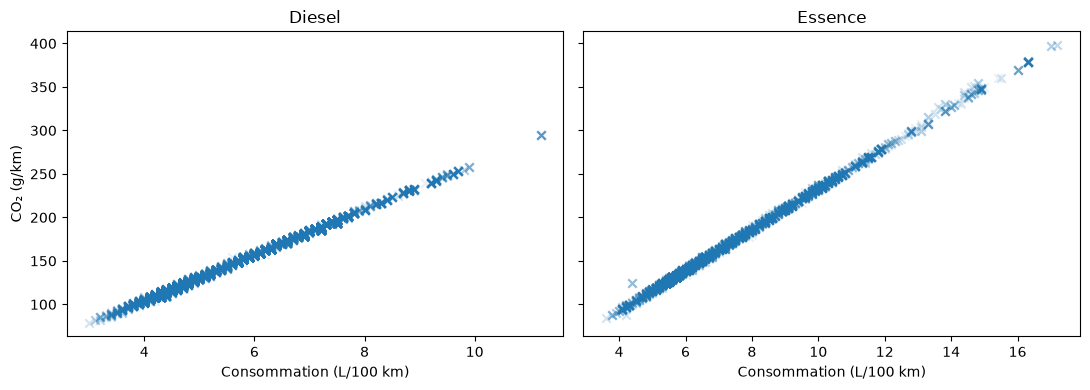

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, (code_energ, nom) in zip(axes, MOTORISATIONS.items()):
    cs = df[df["energ"] == code_energ][["conso_mixte", "co2_mixte"]].dropna()
    ratio = cs["co2_mixte"] / cs["conso_mixte"]
    print(f"{nom:8s}  moyenne = {ratio.mean():6.2f}   ecart-type = {ratio.std():.2f}"
          f"   [{ratio.min():.1f} ; {ratio.max():.1f}]   n = {len(cs)}")
    ax.scatter(cs["conso_mixte"], cs["co2_mixte"], marker="x", alpha=0.1)
    ax.set(xlabel="Consommation (L/100 km)", title=nom)

axes[0].set_ylabel("CO₂ (g/km)")
plt.tight_layout()
plt.show()

Le rapport `CO₂ / conso_mixte` est quasi constant : `26,15` en moyenne pour le diesel et `23,27` pour l'essence. Autrement dit, `CO₂ ≈ 26,15 × conso` pour le diesel et `CO₂ ≈ 23,27 × conso` pour l'essence. La consommation constitue donc une fuite de données, puisque le `CO₂` en est une fonction déterministe.

**Conclusion :** `conso_mixte`, `conso_urb_93` et `conso_exurb` sont exclues de la modélisation.

*(Je conserve `conso_mixte` dans le jeu de travail uniquement pour la démonstration chiffrée de la partie I, et non comme variable explicative.)*

### 0.2 — Seconde fuite : `puiss_admin`

Celle-ci est mieux cachée : la puissance administrative française se calcule depuis 1998 par une formule officielle qui fait intervenir le CO₂.

$$\text{CV} = \frac{\text{CO}_2}{45} + \left(\frac{P}{40}\right)^{1{,}6}$$

Si la formule reproduit la colonne, `puiss_admin` est une fonction déterministe de la cible.

In [3]:
pa_calc = df["co2_mixte"] / 45 + (df["puiss_max"] / 40) ** 1.6
ecart = (pa_calc.round() - df["puiss_admin"]).abs()

print(ecart.describe())
print(f"\nLignes reproduites exactement : {(ecart == 0).mean():.2%}")

count    20824.000000
mean         0.003073
std          0.062678
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          2.000000
dtype: float64

Lignes reproduites exactement : 99.47%


La formule reproduit la colonne à 99,47 %. `puiss_admin` constitue donc bien une fuite de données.

**Conclusion :** `puiss_admin` est exclue de la modélisation.

Cette fuite n'était pas facile à repérer, car la relation entre `puiss_admin` et `CO₂` n'est pas linéaire : l'exposant 1,6 la ferait passer sous le radar d'une simple matrice de corrélation.

Même raisonnement pour `co_typ_1`, `hc`, `nox`, `hcnox` et `ptcl` : ce sont des émissions mesurées sur le même cycle d'essai que le `CO₂`, donc des sorties de mesure et non des caractéristiques de conception.

### 0.3 — Une ligne n'est pas un véhicule

Le fichier déclare les véhicules au niveau de la **variante d'homologation** : mêmes masse, puissance et CO₂, mais numéros de dossier différents. Un modèle déclaré en 18 versions pèse 18 fois plus lourd dans la somme des carrés.

In [4]:
# Clés d'identification d'un véhicule réel.
# La masse est incluse volontairement : les finitions d'un même modèle ont des masses
# différentes, et cette variation est une information, pas un doublon.
CLES = ["lib_mrq_doss", "lib_mod_doss", "masse_ordma_min", "puiss_max", "co2_mixte"]

# Colonnes conservées dans le jeu de travail
GARDEES = ["lib_mrq_doss", "lib_mod_doss", "hybride", "typ_boite_nb_rapp",
           "masse_ordma_min", "puiss_max", "co2_mixte",
           "conso_mixte"]   # fuite — gardée pour la démonstration de la partie I

ESSENTIELLES = ["masse_ordma_min", "puiss_max", "co2_mixte"]


def prepare(code_energ):
    """Filtre sur une motorisation, supprime les NaN et les doublons d'homologation."""
    sous = df[df["energ"] == code_energ][GARDEES].dropna(subset=ESSENTIELLES)
    avant = len(sous)
    sous = sous.drop_duplicates(subset=CLES)
    sous["puiss_max2"] = sous["puiss_max"] ** 2
    print(f"{MOTORISATIONS[code_energ]:8s} {avant:6d} lignes -> {len(sous):5d} vehicules"
          f"   ({avant / len(sous):.1f} declarations par vehicule)")
    return sous


d_go = prepare("GO")
d_es = prepare("ES")

Diesel    12675 lignes ->  3077 vehicules   (4.1 declarations par vehicule)
Essence    6934 lignes ->  2406 vehicules   (2.9 declarations par vehicule)


Pour une motorisation donnée, il y a **plusieurs déclarations pour le même véhicule**. Ce constat n'a rien d'anecdotique : un véhicule déclaré plusieurs fois pèsera davantage qu'un véhicule déclaré une seule fois dans l'ajustement du modèle.

Pour la suite, nous travaillerons donc sur ces données dédupliquées.

In [5]:
def evalue(d, noms, cible="co2_mixte"):
    """Ajuste une régression et renvoie (modèle, R², MAE) sur les données d'entraînement."""
    X, y = d[noms].values, d[cible].values
    m = LinearRegression().fit(X, y)
    p = m.predict(X)
    return m, r2_score(y, p), mean_absolute_error(y, p)

## Partie I — Régression multiple sur les diesels

Deux modèles à comparer :

- **Modèle A** — masse + puissance : ce qu'un constructeur connaît au moment de la conception
- **Modèle B** — le même, plus `conso_mixte` : pour montrer chiffres à l'appui ce que fait une fuite

In [6]:
for nom, noms in [("A (conception)", ["masse_ordma_min", "puiss_max"]),
                  ("B (avec conso)", ["masse_ordma_min", "puiss_max", "conso_mixte"])]:
    m, r2, mae = evalue(d_go, noms)
    print(f"\nModele {nom} - R2 = {r2:.3f}   MAE = {mae:.1f} g/km")
    for v, c in zip(noms, m.coef_):
        print(f"   {v:18s} {c:9.3f}")


Modele A (conception) - R2 = 0.775   MAE = 12.5 g/km
   masse_ordma_min        0.085
   puiss_max             -0.028

Modele B (avec conso) - R2 = 0.999   MAE = 0.9 g/km
   masse_ordma_min       -0.001
   puiss_max              0.005
   conso_mixte           26.423


Dans le modèle B, les coefficients de la `masse` et de la `puissance` ont quasiment disparu (−0,001 et 0,005) face à celui de la `consommation`, qui écrase tout le reste.
Le R² du modèle B est presque égal à 1 (0,999) et la MAE tombe à 0,9 g/km.

Surtout, le coefficient de `conso_mixte` (26,423) est presque égal au rapport `CO₂ / conso_mixte` trouvé en 0.1. Autrement dit, le modèle n'a rien appris : il s'est contenté de retrouver une relation déterministe. Ce coefficient correspond en effet au facteur d'émission du gazole — 26,4 g de CO₂ par km pour 1 L/100 km, soit environ 2,64 kg de CO₂ par litre brûlé. Le CO₂ homologué étant calculé à partir de la consommation, `conso_mixte` constitue une fuite de données (*data leakage*).

**Conclusion :** le modèle B doit être écarté pour la suite, précisément *à cause* de son bon score : celui-ci ne mesure pas une capacité de prédiction, mais une identité comptable.

À noter également que le R² du modèle A (0,806) est quasi identique à celui de la régression simple sur la masse seule (0,805) : **la puissance n'apporte donc rien chez les diesels.**